**Membros do grupo:**
* Ana Luiza Macêdo dos Santos [matrícula]
* Hector Julio Pardinho Soares [matrícula]
* Laura Godinho Barroso [matrícula]
* Mariane Mara de Souza [matrícula]
* Salvador Cândido da Silva Júnior [matrícula]

In [1]:
import pandas as pd
import pysubgroup as ps
from itertools import product
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_colwidth', None)
#pd.set_option('display.width', 2000)
pd.set_option('display.max_columns', None)

# 1. Business Understanding

# 2. Data Understanding

In [2]:
raw_data_07 = pd.read_csv('datatran2007.csv', encoding='latin-1', sep=';')
raw_data_07.head()

C:\Users\Hector\AppData\Local\Temp\ipykernel_6412\3009182282.py:1: DtypeWarning: Columns (0: br, 1: km) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data_07 = pd.read_csv('datatran2007.csv', encoding='latin-1', sep=';')


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,ano,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos
0,10,11/06/2007,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,(null),Pleno dia,Decrescente,Ceu Claro,Dupla,Reta,Rural,2007,9,0,4,0,5,0,4,6
1,10,11/06/2007,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,(null),Pleno dia,Decrescente,Chuva,Dupla,Reta,Rural,2007,9,0,4,0,5,0,4,6
2,1032898,13/08/2007,Segunda,14:25:00,MG,40,585.5,ITABIRITO,Outras,Saída de Pista,Com Vítimas Feridas,Pleno dia,Crescente,Ceu Claro,Simples,Reta,Rural,2007,3,0,0,1,2,0,1,1
3,1051130,12/02/2007,Segunda,02:10:00,MA,135,11.0,SAO LUIS,Animais na Pista,Atropelamento de animal,Com Vítimas Fatais,Plena noite,Crescente,Ceu Claro,Simples,Reta,Urbano,2007,5,2,2,1,0,0,3,1
4,1066824,20/11/2007,Terça,05:30:00,CE,222,30.8,CAUCAIA,Defeito mecânico em veículo,Capotamento,Com Vítimas Feridas,Amanhecer,Decrescente,Ceu Claro,Dupla,Reta,Rural,2007,1,0,1,0,0,0,1,1


In [3]:

raw_data_25 = pd.read_csv('datatran2025.csv', encoding='latin-1', sep=';')
raw_data_25.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


In [4]:
def missing_values_of_dataset(df):
    """Prints missing values for a dataframe."""

    print("==================================================")
    print("1. MISSING VALUES & INFOS PER COLUMN")
    print("==================================================")
    missing_count = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df)) * 100

    missing_df = pd.DataFrame(
        {"Missing Count": missing_count, "Percentage (%)": missing_pct}
    )
    print(missing_df.to_string())
    print("\n")

In [23]:
print('2025')
missing_values_of_dataset(raw_data_25)
print('2007')
missing_values_of_dataset(raw_data_07)

2025
1. MISSING VALUES & INFOS PER COLUMN
                        Missing Count  Percentage (%)
id                                  0        0.000000
data_inversa                        0        0.000000
dia_semana                          0        0.000000
horario                             0        0.000000
uf                                  0        0.000000
br                                  0        0.000000
km                                  0        0.000000
municipio                           0        0.000000
causa_acidente                      0        0.000000
tipo_acidente                       0        0.000000
classificacao_acidente              1        0.001379
fase_dia                            0        0.000000
sentido_via                         0        0.000000
condicao_metereologica              0        0.000000
tipo_pista                          0        0.000000
tracado_via                         0        0.000000
uso_solo                            0   

In [ ]:
def plotar_contagem_categorica(
    df, coluna, titulo=None, cor="skyblue", top_n=None, ax=None
):
    """Gera um gráfico de barras com a contagem absoluta e o percentual de uma variável.

    Pode ser usada individualmente ou dentro de uma grade de múltiplos gráficos.
    """
    if coluna not in df.columns:
        print(f"Erro: A coluna '{coluna}' não existe no DataFrame.")
        return

    dados_filtrados = df[coluna].dropna().astype(str)
    total_registros = len(dados_filtrados)

    if total_registros == 0:
        return

    ordem_categorias = dados_filtrados.value_counts().index
    if top_n is not None:
        ordem_categorias = ordem_categorias[:top_n]

    # SE ESTIVERMOS PLOTANDO LADO A LADO, USAMOS O AX PASSADO.
    # CASO CONTRÁRIO, CRIAMOS UMA FIGURA NOVA (COMPATIBILIDADE).
    if ax is None:
        plt.figure(figsize=(10, 6))
        sns.set_theme(style="whitegrid")
        ax = plt.gca()

    # Cria o gráfico de barras associando ao eixo específico (ax)
    sns.countplot(
        data=df,
        x=coluna,
        order=ordem_categorias,
        color=cor,
        edgecolor="black",
        linewidth=0.7,
        ax=ax,
    )

    # Configurações de títulos e rótulos no eixo atual
    titulo_grafico = titulo if titulo else f"Distribuição: {coluna}"
    ax.set_title(titulo_grafico, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel(coluna.replace("_", " ").title(), fontsize=10, labelpad=8)
    ax.set_ylabel("Contagem (Frequência)", fontsize=10, labelpad=8)

    # Rotaciona rótulos do eixo X
    current_ticks = ax.get_xticks()
    current_labels = [label.get_text() for label in ax.get_xticklabels()]
    ax.set_xticks(current_ticks)
    ax.set_xticklabels(
        current_labels, rotation=45, ha="right", fontsize=9
    )

    # Adiciona rótulos com Contagem e Percentual no topo de cada barra
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            percentual = (altura / total_registros) * 100
            label = f"{int(altura)}\n({percentual:.1f}%)"

            ax.annotate(
                label,
                (p.get_x() + p.get_width() / 2.0, altura),
                ha="center",
                va="center",
                xytext=(0, 10),
                textcoords="offset points",
                fontsize=8.5,
                fontweight="semibold",
            )

    # Margem de segurança no topo do gráfico atual
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

    # Se a função foi chamada individualmente, mostra o gráfico
    if ax == plt.gca() and ax.figure.images == []:
        plt.tight_layout()
        plt.show()

In [7]:
def plotar_multiplos_categoricos(df, colunas, n_colunas=3, top_n=8):
    """Cria um único canvas com múltiplos gráficos de contagem organizados em uma grade.

    Parâmetros:
    - df: DataFrame do Pandas.
    - colunas: Lista de strings com os nomes das colunas categóricas.
    - n_colunas: Quantidade de gráficos que ficarão lado a lado (padrão: 3).
    - top_n: Limite de categorias principais exibidas por gráfico.
    """
    n_graficos = len(colunas)

    # Calcula automaticamente quantas linhas serão necessárias para acomodar os k gráficos
    n_linhas = math.ceil(n_graficos / n_colunas)

    # Define o tamanho dinâmico do canvas (largura fixa proporcional, altura expande por linha)
    fig, eixos = plt.subplots(
        nrows=n_linhas,
        ncols=n_colunas,
        figsize=(6 * n_colunas, 5 * n_linhas),
        squeeze=False,
    )
    sns.set_theme(style="whitegrid")

    # Transforma a matriz de eixos em uma lista achatada (1D) para iterar facilmente
    eixos_achatados = eixos.flatten()

    # Paleta de cores para os subplots não ficarem todos iguais
    cores = sns.color_palette("Set2", n_graficos)

    # Plota cada variável em seu respectivo quadrante
    for i, coluna in enumerate(colunas):
        plotar_contagem_categorica(
            df=df,
            coluna=coluna,
            cor=cores[i],
            top_n=top_n,
            ax=eixos_achatados[i],  # Passa o quadrante específico
        )

    # Esconde os eixos vazios que sobrarem na grade (ex: pedir 5 gráficos em uma grade de 3x2)
    for j in range(i + 1, len(eixos_achatados)):
        fig.delaxes(eixos_achatados[j])

    # Ajusta o espaçamento para que as legendas de um gráfico não entrem no outro
    plt.tight_layout()
    plt.show()

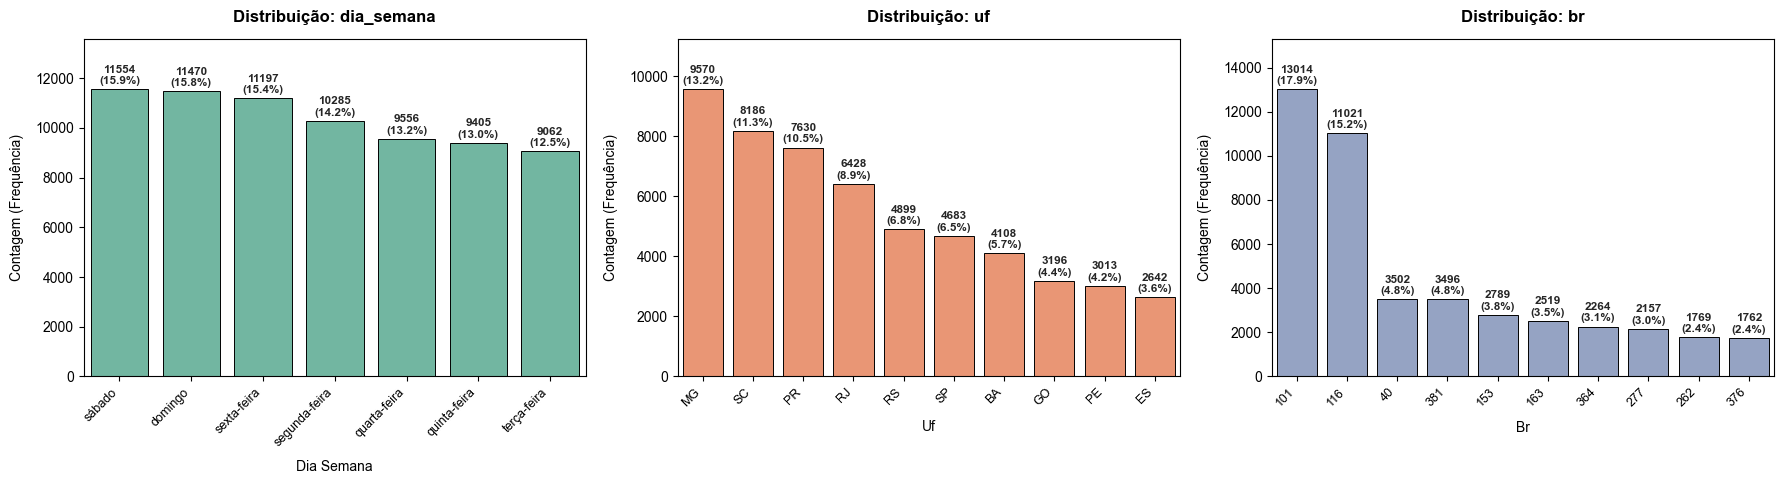

<Figure size 640x480 with 0 Axes>

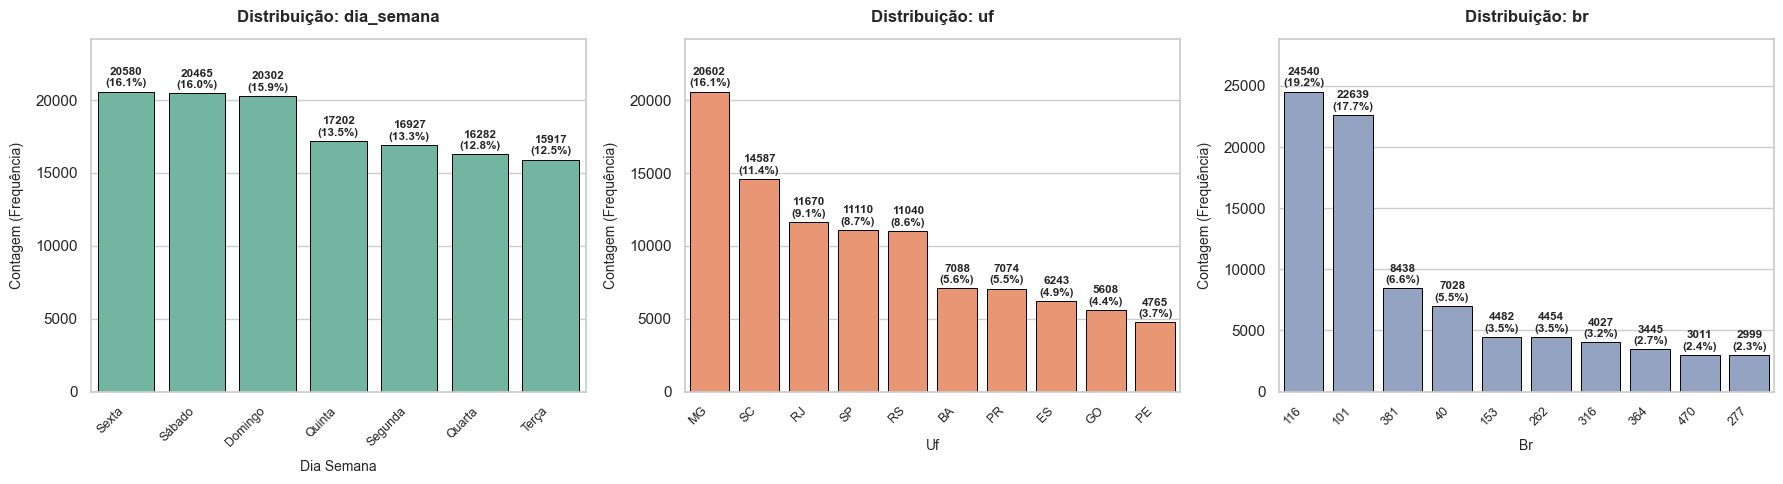

<Figure size 640x480 with 0 Axes>

In [8]:
# Lista de colunas que você quer colocar lado a lado
minhas_variaveis_1 = [
    "dia_semana",
    "uf",
    "br"
]

# Chama a função mestre para plotar em um grid de 3 colunas
plotar_multiplos_categoricos(df=raw_data_25, colunas=minhas_variaveis_1, n_colunas=3, top_n=10)
plotar_multiplos_categoricos(df=raw_data_07, colunas=minhas_variaveis_1, n_colunas=3, top_n=10)

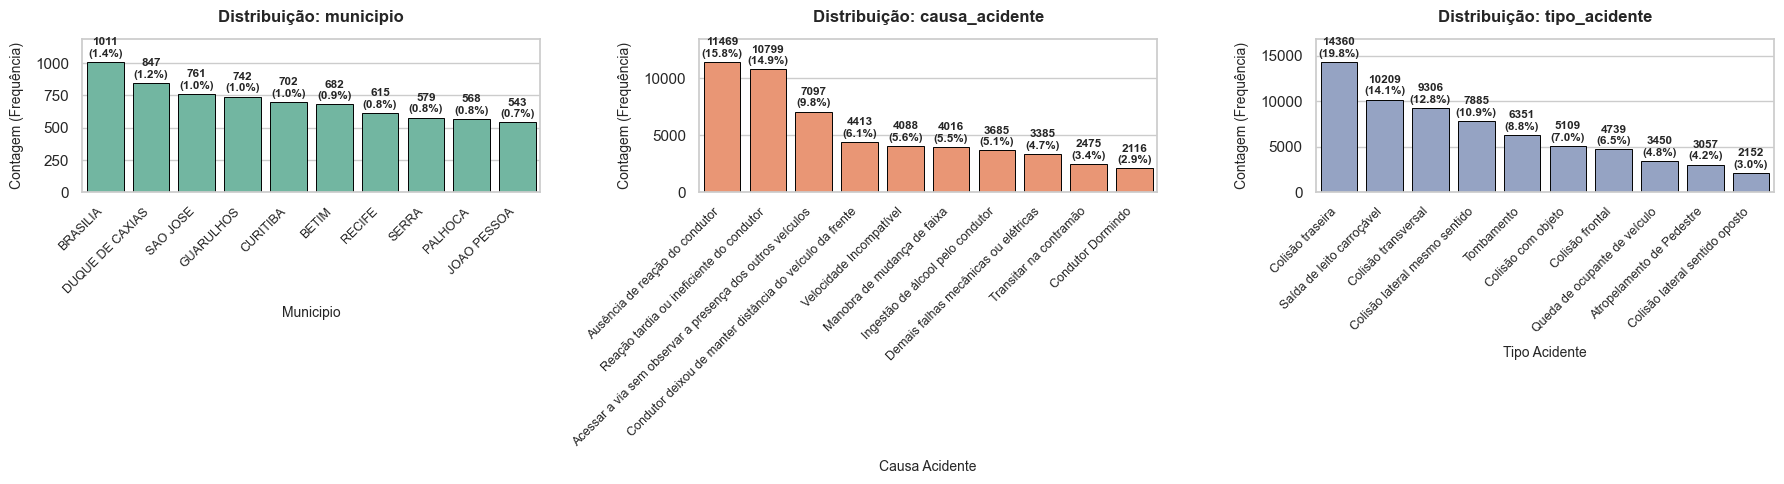

<Figure size 640x480 with 0 Axes>

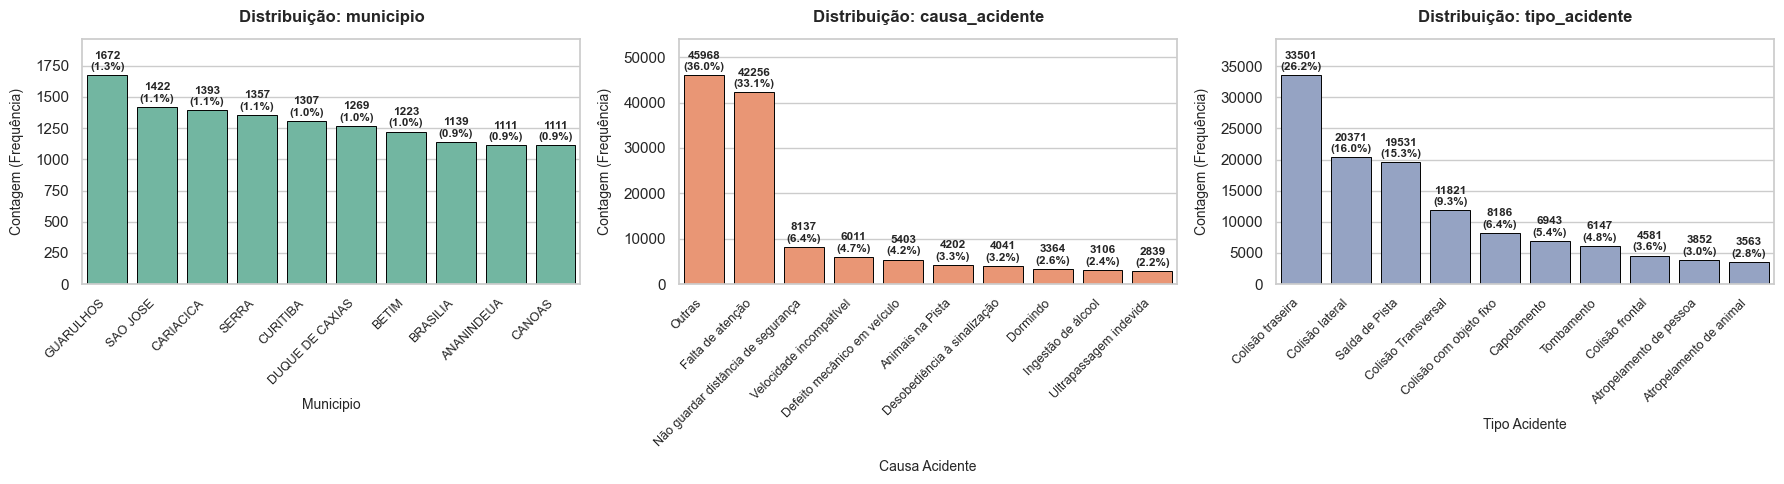

<Figure size 640x480 with 0 Axes>

In [9]:
# Lista de colunas que você quer colocar lado a lado
minhas_variaveis_2 = [
    'municipio',
    'causa_acidente',
    'tipo_acidente'
]

# Chama a função mestre para plotar em um grid de 3 colunas
plotar_multiplos_categoricos(df=raw_data_25, colunas=minhas_variaveis_2, n_colunas=3, top_n=10)
plotar_multiplos_categoricos(df=raw_data_07, colunas=minhas_variaveis_2, n_colunas=3, top_n=10)

Plotando 2025...


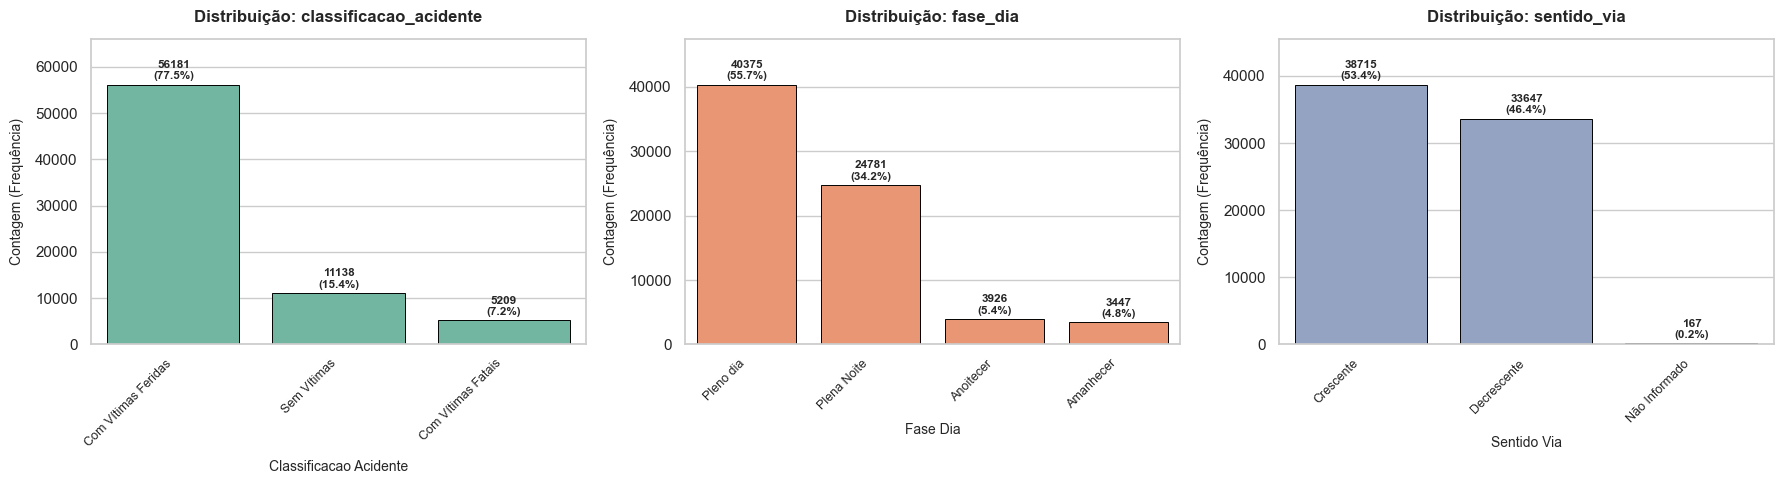

<Figure size 640x480 with 0 Axes>

Plotando 2007...


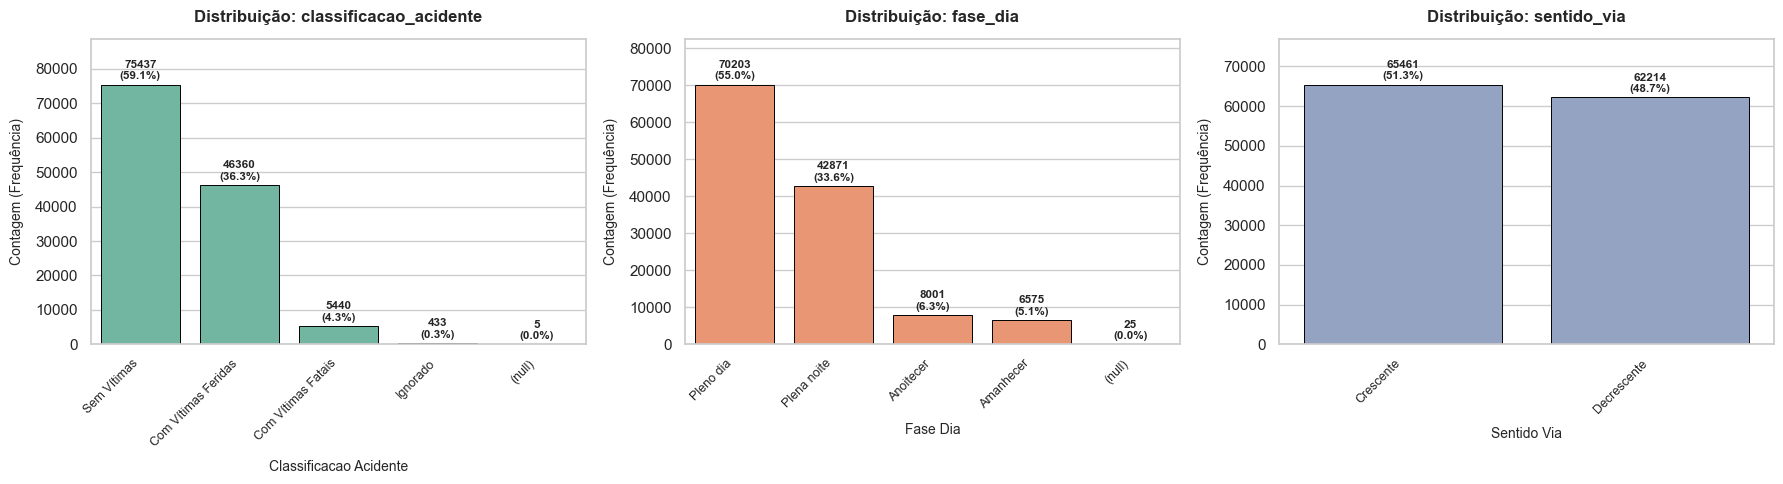

<Figure size 640x480 with 0 Axes>

In [10]:
# Lista de colunas que você quer colocar lado a lado
minhas_variaveis_3 = [
    'classificacao_acidente',
    'fase_dia',
    'sentido_via'
]

# Chama a função mestre para plotar em um grid de 3 colunas
print("Plotando 2025...")
plotar_multiplos_categoricos(df=raw_data_25, colunas=minhas_variaveis_3, n_colunas=3, top_n=10)
print("Plotando 2007...")
plotar_multiplos_categoricos(df=raw_data_07, colunas=minhas_variaveis_3, n_colunas=3, top_n=10)

Plotando 2025...


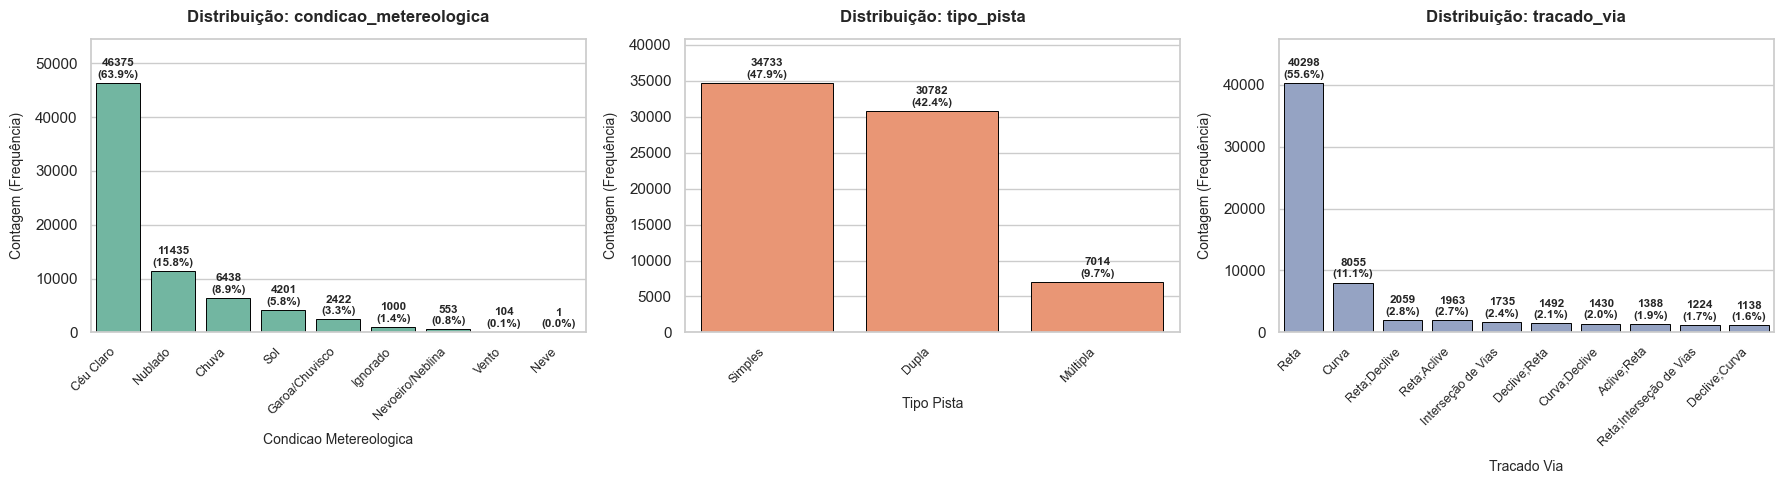

<Figure size 640x480 with 0 Axes>

Plotando 2007...


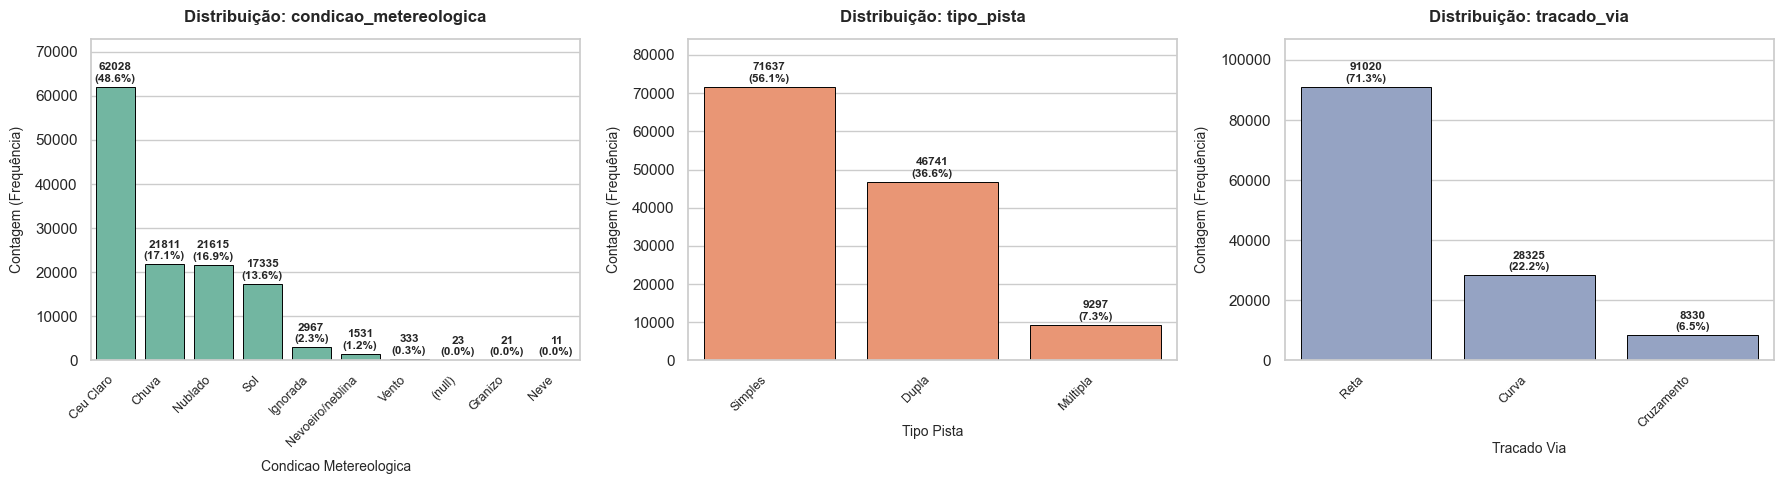

<Figure size 640x480 with 0 Axes>

In [11]:
# Lista de colunas que você quer colocar lado a lado
minhas_variaveis_4 = [
    'condicao_metereologica',
    'tipo_pista',
    'tracado_via'
]

# Chama a função mestre para plotar em um grid de 3 colunas
print("Plotando 2025...")
plotar_multiplos_categoricos(df=raw_data_25, colunas=minhas_variaveis_4, n_colunas=3, top_n=10)
print("Plotando 2007...")
plotar_multiplos_categoricos(df=raw_data_07, colunas=minhas_variaveis_4, n_colunas=3, top_n=10)

Plotando 2025...


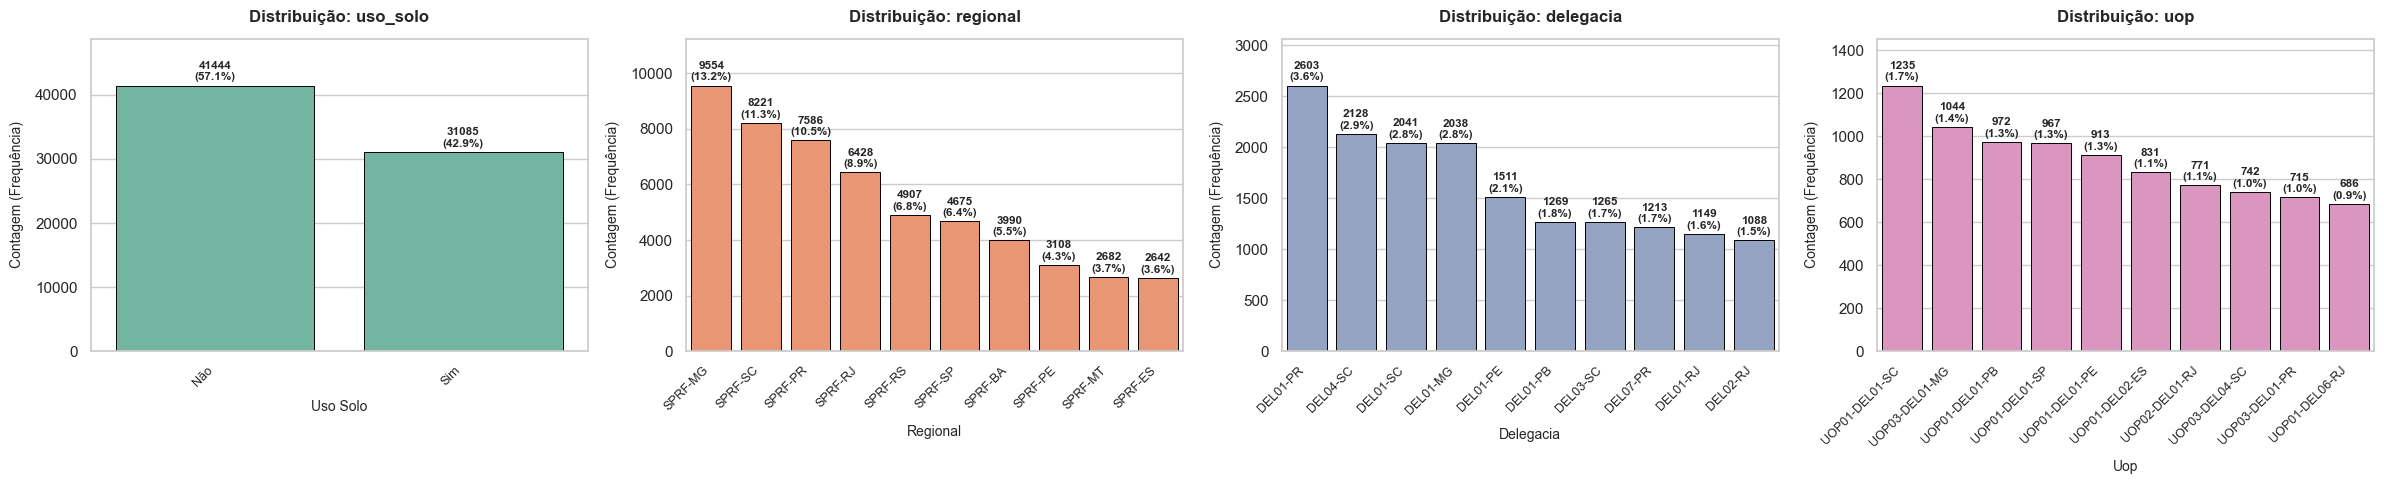

<Figure size 640x480 with 0 Axes>

Plotando 2007...
Erro: A coluna 'regional' não existe no DataFrame.
Erro: A coluna 'delegacia' não existe no DataFrame.
Erro: A coluna 'uop' não existe no DataFrame.


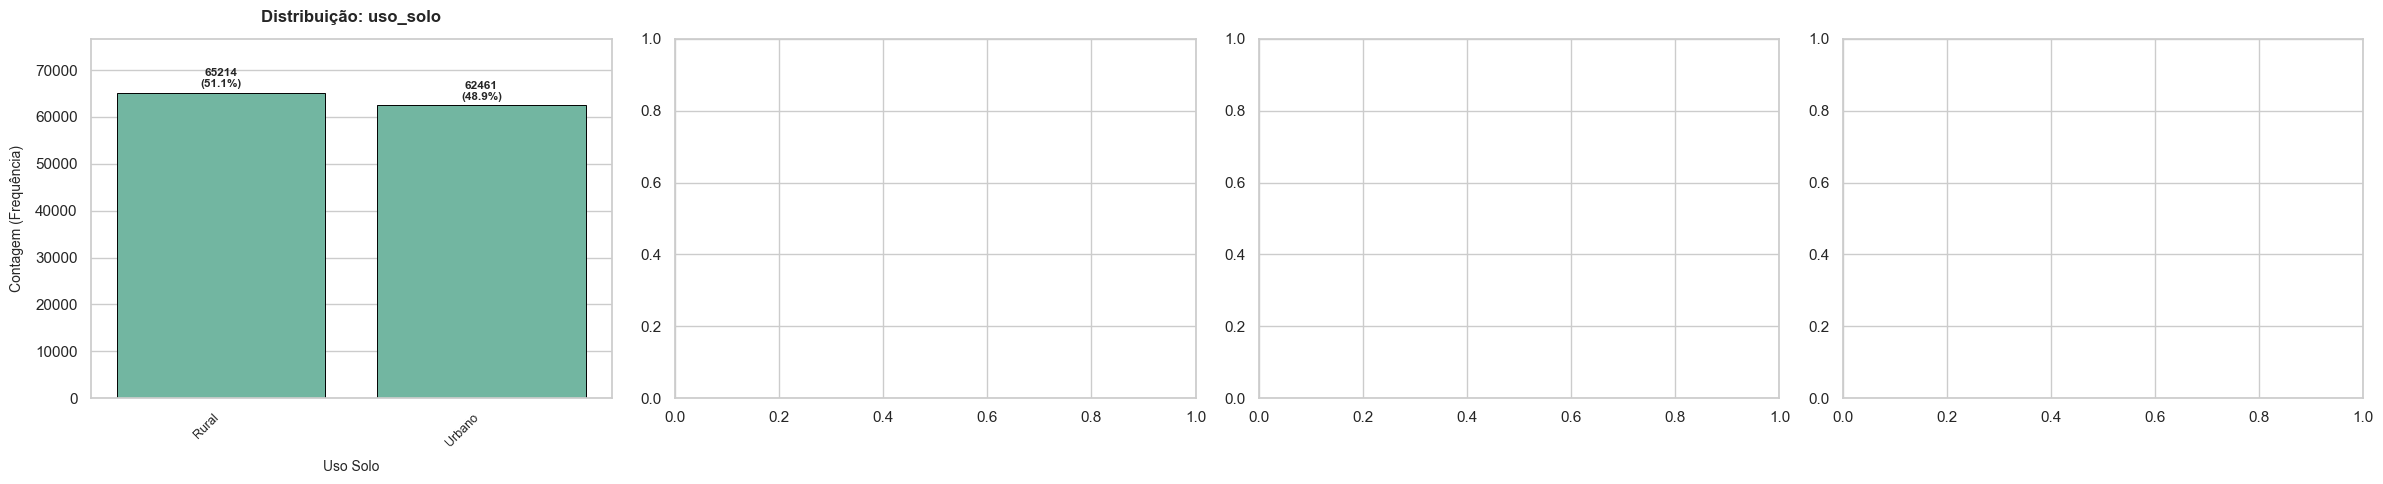

In [12]:
# Lista de colunas que você quer colocar lado a lado
minhas_variaveis_5 = [
    'uso_solo',
    'regional',
    'delegacia',
    'uop'
]

print("Plotando 2025...")
plotar_multiplos_categoricos(df=raw_data_25, colunas=minhas_variaveis_5, n_colunas=4, top_n=10)
print("Plotando 2007...")
plotar_multiplos_categoricos(df=raw_data_07, colunas=minhas_variaveis_5, n_colunas=4, top_n=10)

# 3. Data Preparation

In [ ]:
def padronizar_nomenclaturas(df, colunas_categoricas):
    """
    Harmoniza os dados de 2007 e 2025 mapeando as nomenclaturas novas 
    de volta para os macrogrupos clássicos, garantindo uma comparação justa.
    """
    df_padronizado = df.copy()

    # 1. Padronização inicial: minúsculas e sem espaços extras
    for c in colunas_categoricas:
        df_padronizado[c] = df_padronizado[c].astype(str).str.strip().str.lower()

    # 2. HARMONIZAÇÃO DE DICIONÁRIOS (A Mágica acontece aqui)

    # --- Condição Meteorológica ---
    df_padronizado['condicao_metereologica'] = df_padronizado['condicao_metereologica'].replace({
        'ceu claro': 'céu claro',  # Corrige o acento ausente em 2007!
        'ignorada': 'ignorado'
    })

    # --- Uso do Solo ---
    df_padronizado['uso_solo'] = df_padronizado['uso_solo'].replace({
        'rural': 'não',
        'urbano': 'sim'
    })

    # --- Tipo de Acidente ---
    df_padronizado['tipo_acidente'] = df_padronizado['tipo_acidente'].replace({
        # Atualizações de 2007 -> 2025
        'atropelamento de pessoa': 'atropelamento de pedestre',
        'saída de pista': 'saída de leito carroçável',
        'queda de motocicleta / bicicleta / veículo': 'queda de ocupante de veículo',
        
        # Unificando categorias separadas
        'colisão com objeto fixo': 'colisão com objeto',
        'colisão com objeto móvel': 'colisão com objeto',
        
        # Agrupando as subdivisões modernas (2025) de volta no termo macro (2007)
        'colisão lateral mesmo sentido': 'colisão lateral',
        'colisão lateral sentido oposto': 'colisão lateral'
    })

    # --- Causa do Acidente ---
    # Traduzindo as causas hiper-específicas de 2025 para os 11 macrogrupos de 2007
    df_padronizado['causa_acidente'] = df_padronizado['causa_acidente'].replace({
        'condutor dormindo': 'dormindo',
        'ingestão de álcool pelo condutor': 'ingestão de álcool',
        'pedestre - ingestão de álcool/ substâncias psicoativas': 'ingestão de álcool',
        'condutor deixou de manter distância do veículo da frente': 'não guardar distância de segurança',
        'ausência de reação do condutor': 'falta de atenção',
        'condutor usando celular': 'falta de atenção',
        'reação tardia ou ineficiente do condutor': 'falta de atenção',
        
        # Agrupando defeitos mecânicos
        'problema com o freio': 'defeito mecânico em veículo',
        'problema na suspensão': 'defeito mecânico em veículo',
        'avarias e/ou desgaste excessivo no pneu': 'defeito mecânico em veículo',
        'demais falhas mecânicas ou elétricas': 'defeito mecânico em veículo',
        
        # Agrupando defeitos na via
        'pista esburacada': 'defeito na via',
        'afundamento ou ondulação no pavimento': 'defeito na via',
        'demais falhas na via': 'defeito na via',
        
        # Agrupando desobediência
        'condutor desrespeitou a iluminação vermelha do semáforo': 'desobediência à sinalização',
        'desrespeitar a preferência no cruzamento': 'desobediência à sinalização'
    })

    # 2. O FILTRO "OUTRAS" (A Mágica)
    # Lista das 10 causas específicas exatas que existiam em 2007
    causas_2007_exatas = [
        'animais na pista', 'defeito mecânico em veículo', 'defeito na via', 
        'desobediência à sinalização', 'dormindo', 'falta de atenção', 
        'ingestão de álcool', 'não guardar distância de segurança', 
        'ultrapassagem indevida', 'velocidade incompatível'
    ]

    # Tudo o que NÃO estiver na lista acima (e não for nulo), é transformado em 'outras'
    mask_not_null = df_padronizado['causa_acidente'].notna()
    mask_not_in_2007 = ~df_padronizado['causa_acidente'].isin(causas_2007_exatas)
    
    df_padronizado.loc[mask_not_null & mask_not_in_2007, 'causa_acidente'] = 'outras'

    # 3. Tratamento de Nulos Ocultos
    # O Pandas às vezes não entende a string '(null)' gerada pelo banco antigo
    df_padronizado = df_padronizado.replace({'(null)': np.nan, 'nan': np.nan})
    
    return df_padronizado

In [26]:

colunas_em_comum = ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km','municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 
    'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 
    'feridos', 'veiculos'
]

df07 = raw_data_07[colunas_em_comum]                
df25 = raw_data_25[colunas_em_comum]



def preprocess(df):
    df = df.copy()

    # Target binário: acidente com vítima fatal
    df['fatal'] = (df['mortos'] > 0).astype(int)

    # Turno do dia a partir do horário
    df['horario'] = df['horario'].astype(str).str[:2]
    df['horario'] = pd.to_numeric(df['horario'], errors='coerce')
    df['turno'] = pd.cut(
        df['horario'],
        bins=[-1, 5, 11, 17, 23],
        labels=['madrugada', 'manha', 'tarde', 'noite']
    )

    # Colunas categóricas que usaremos como features
    cats = [
        'dia_semana', 'uf', 'causa_acidente', 'tipo_acidente',
        'fase_dia', 'condicao_metereologica', 'tipo_pista',
        'tracado_via', 'uso_solo', 'turno'
    ]
    for c in cats:
        df[c] = df[c].astype(str).str.strip().str.lower()

    df = padronizar_nomenclaturas(df, cats)

    df = df.dropna(subset=['fatal'] + cats)
    return df, cats

df07_clean, cats = preprocess(df07)
df25_clean, _    = preprocess(df25)

# 4. Modeling

In [27]:
def run_sd(df, cats, target_col='fatal', top_k=20, depth=3):
    """Retorna top-K subgrupos ordenados por WRAcc."""
    target = ps.BinaryTarget(target_col, True)

    searchspace = ps.create_selectors(df, ignore=[target_col])
    # Filtra para usar só as colunas categóricas que preparamos
    searchspace = [s for s in searchspace
                   if any(c in str(s) for c in cats)]

    task = ps.SubgroupDiscoveryTask(
        df,
        target,
        searchspace,
        result_set_size=top_k,
        depth=depth,
        qf=ps.WRAccQF()          # Weighted Relative Accuracy
    )

    with np.errstate(divide='ignore', invalid='ignore'):
        result = ps.BeamSearch().execute(task)
    return result.to_dataframe()

print("Rodando SD em 2007...")
res07 = run_sd(df07_clean, cats)

print("Rodando SD em 2025...")
res25 = run_sd(df25_clean, cats)

Rodando SD em 2007...
Rodando SD em 2025...


# 5. Evaluation

In [28]:
def subgroup_to_str(sg):
    return str(sg).strip().lower()

# Mapeia string -> linha original para recuperar métricas
map07 = {subgroup_to_str(r['subgroup']): r for _, r in res07.iterrows()}
map25 = {subgroup_to_str(r['subgroup']): r for _, r in res25.iterrows()}

set07 = set(map07.keys())
set25 = set(map25.keys())

jaccard = len(set07 & set25) / len(set07 | set25) if set07 | set25 else 0

def make_table(keys, map_principal, map_secundario=None):
    rows = []
    for k in sorted(keys):
        r = map_principal[k]
        row = {
            'subgrupo': k,
            'quality':  round(r['quality'], 4),
            'tamanho':  int(r['size_sg']),
            'p(fatal)': round(r['target_share_sg'], 4),
        }
        if map_secundario and k in map_secundario:
            r2 = map_secundario[k]
            row['quality_outro_ano'] = round(r2['quality'], 4)
            row['tamanho_outro_ano'] = int(r2['size_sg']) 
            row['p(fatal)_outro_ano'] = round(r2['target_share_sg'], 4)
        rows.append(row)
    return pd.DataFrame(rows)

In [29]:
# ==============================================================================
# 2. CRIAÇÃO DOS DATAFRAMES
# ==============================================================================
df_persistentes = make_table(set07 & set25, map07, map25)
df_novos        = make_table(set25 - set07, map25)
df_extintos     = make_table(set07 - set25, map07)

# ==============================================================================
# 3. PADRONIZAÇÃO E CONSOLIDAÇÃO NA TABELA ÚNICA
# ==============================================================================
# Adiciona a coluna de status
df_persistentes['status'] = 'Persistente'
df_novos['status']        = 'Novo em 2025'
df_extintos['status']     = 'Extinto desde 2007'

# Renomeia as colunas para que todas fiquem com o ano explícito
df_persistentes = df_persistentes.rename(columns={
    'quality':           'quality_2007',
    'tamanho':           'tamanho_2007',
    'p(fatal)':          'p(fatal)_2007',
    'quality_outro_ano': 'quality_2025',
    'tamanho_outro_ano': 'tamanho_2025',
    'p(fatal)_outro_ano':'p(fatal)_2025',
})

df_novos = df_novos.rename(columns={
    'quality':  'quality_2025',
    'tamanho':  'tamanho_2025',
    'p(fatal)': 'p(fatal)_2025'
})

df_extintos = df_extintos.rename(columns={
    'quality':  'quality_2007',
    'tamanho':  'tamanho_2007',
    'p(fatal)': 'p(fatal)_2007'
})

# Concatena (junta) tudo em uma única tabela
df_tabela_final = pd.concat([df_persistentes, df_novos, df_extintos], ignore_index=True)

# Reorganiza a ordem das colunas para facilitar a leitura
colunas_ordem = [
    'subgrupo', 'status', 
    'quality_2007', 'tamanho_2007', 'p(fatal)_2007',
    'quality_2025', 'tamanho_2025', 'p(fatal)_2025'
]
df_tabela_final = df_tabela_final[colunas_ordem]

### 4. RESULTADOS E EXPORTAÇÃO

In [30]:
print(f"Jaccard: {jaccard:.2f}")

# Salva a tabela consolidada num arquivo CSV (pode ser aberto no Excel)
df_tabela_final.to_csv("tabela_consolidada_subgrupos.csv", index=False)

display(df_tabela_final)

Jaccard: 0.48


,subgrupo,status,quality_2007,tamanho_2007,p(fatal)_2007,quality_2025,tamanho_2025,p(fatal)_2025
0,fase_dia=='plena noite',Persistente,0.0064,42864.0,0.0618,0.0102,24781.0,0.1018
1,fase_dia=='plena noite' and tipo_pista=='simples',Persistente,0.0063,24747.0,0.0751,0.0101,12244.0,0.1315
2,fase_dia=='plena noite' and uso_solo=='não',Persistente,0.0055,22585.0,0.0739,0.0104,14452.0,0.1238
3,tipo_acidente=='atropelamento de pedestre',Persistente,0.0068,3852.0,0.2687,0.0094,3057.0,0.2951
4,tipo_acidente=='colisão frontal',Persistente,0.0077,4577.0,0.2563,0.0146,4739.0,0.2946
5,tipo_acidente=='colisão frontal' and tipo_pista=='simples',Persistente,0.0073,3995.0,0.2758,0.0141,4236.0,0.3128
6,tipo_acidente=='colisão frontal' and tipo_pista=='simples' and uso_solo=='não',Persistente,0.0061,2723.0,0.3276,0.0126,3133.0,0.3629
7,tipo_acidente=='colisão frontal' and uso_solo=='não',Persistente,0.0063,2914.0,0.3181,0.0129,3359.0,0.3513
8,tipo_pista=='simples',Persistente,0.0068,71613.0,0.0548,0.0128,34733.0,0.0986
9,tipo_pista=='simples' and tracado_via=='reta',Persistente,0.0062,48387.0,0.0588,0.0079,17876.0,0.1038


In [31]:
res07['ano'] = 2007
res25['ano'] = 2025
comparativo = pd.concat([res07, res25], ignore_index=True)
comparativo.to_csv("subgrupos_comparativo_bruto.csv", index=False)

colunas_display = {
    'subgroup': 'Subgrupo (Regra)',
    'quality': 'WRAcc (Qualidade)',
    'size_sg': 'Tamanho (Acidentes)',
    'target_share_sg': 'p(fatal)'
}

def formatar_top_k(df, k=5):
    """Pega os top K resultados, limpa o texto e formata os números"""
    df_top = df.head(k).copy()
    df_top['subgroup'] = df_top['subgroup'].apply(lambda x: str(x).strip().lower())
    df_top = df_top[list(colunas_display.keys())].rename(columns=colunas_display)
    
    df_top['WRAcc (Qualidade)'] = df_top['WRAcc (Qualidade)'].round(4)
    df_top['p(fatal)'] = df_top['p(fatal)'].round(4)
    
    return df_top

# Cria as tabelas formatadas
top5_07_formatado = formatar_top_k(res07)
top5_25_formatado = formatar_top_k(res25)

In [32]:
print("=" * 80)
print(" 🏆 TOP 5 SUBGRUPOS MAIS CRÍTICOS - 2007")
print("=" * 80)
try:
    display(top5_07_formatado) 
except NameError:
    print(top5_07_formatado.to_string(index=False)) 

print("\n")
print("=" * 80)
print("TOP 5 SUBGRUPOS MAIS CRÍTICOS - 2025")
print("=" * 80)
try:
    display(top5_25_formatado)
except NameError:
    print(top5_25_formatado.to_string(index=False))

 🏆 TOP 5 SUBGRUPOS MAIS CRÍTICOS - 2007


,Subgrupo (Regra),WRAcc (Qualidade),Tamanho (Acidentes),p(fatal)
0,tipo_pista=='simples' and uso_solo=='não',0.0077,46423,0.0638
1,tipo_acidente=='colisão frontal',0.0077,4577,0.2563
2,tipo_acidente=='colisão frontal' and tipo_pista=='simples',0.0073,3995,0.2758
3,tipo_pista=='simples',0.0068,71613,0.0548
4,tipo_acidente=='atropelamento de pedestre',0.0068,3852,0.2687




TOP 5 SUBGRUPOS MAIS CRÍTICOS - 2025


,Subgrupo (Regra),WRAcc (Qualidade),Tamanho (Acidentes),p(fatal)
0,tipo_pista=='simples' and uso_solo=='não',0.0156,23860,0.1192
1,tipo_acidente=='colisão frontal',0.0146,4739,0.2946
2,tipo_acidente=='colisão frontal' and tipo_pista=='simples',0.0141,4236,0.3128
3,tipo_acidente=='colisão frontal' and uso_solo=='não',0.0129,3359,0.3513
4,tipo_pista=='simples',0.0128,34733,0.0986


In [36]:
# ==============================================================================
# EXPERIMENTO 2: ADICIONANDO NOVAS FEATURES (Fim de Semana e Região)
# ==============================================================================

def preprocess_com_extras(df):
    """Nova função de pré-processamento que mantém o original e adiciona colunas extras"""
    df = df.copy()

    # Target e Turno (Idêntico ao original)
    df['fatal'] = (df['mortos'] > 0).astype(int)
    df['horario'] = df['horario'].astype(str).str[:2]
    df['horario'] = pd.to_numeric(df['horario'], errors='coerce')
    df['turno'] = pd.cut(
        df['horario'],
        bins=[-1, 5, 11, 17, 23],
        labels=['madrugada', 'manha', 'tarde', 'noite']
    )

    # --- NOVAS FEATURES ---
    # 1. Fim de Semana
    dias_fim_semana = ['sábado', 'sabado', 'domingo']
    df['fim_de_semana'] = df['dia_semana'].astype(str).str.lower().apply(
        lambda x: 'sim' if any(d in x for d in dias_fim_semana) else 'não'
    )

    # 2. Região
    mapa_regioes = {
        'ac': 'norte', 'am': 'norte', 'ap': 'norte', 'pa': 'norte', 'ro': 'norte', 'rr': 'norte', 'to': 'norte',
        'al': 'nordeste', 'ba': 'nordeste', 'ce': 'nordeste', 'ma': 'nordeste', 'pb': 'nordeste', 'pe': 'nordeste', 'pi': 'nordeste', 'rn': 'nordeste', 'se': 'nordeste',
        'df': 'centro-oeste', 'go': 'centro-oeste', 'mt': 'centro-oeste', 'ms': 'centro-oeste',
        'es': 'sudeste', 'mg': 'sudeste', 'rj': 'sudeste', 'sp': 'sudeste',
        'pr': 'sul', 'rs': 'sul', 'sc': 'sul'
    }
    df['regiao'] = df['uf'].astype(str).str.lower().map(mapa_regioes)

    # --- LISTA DE CATEGORIAS ATUALIZADA ---
    cats_extras = [
        'dia_semana', 'fim_de_semana', 'uf', 'regiao', 'causa_acidente', 'tipo_acidente',
        'fase_dia', 'condicao_metereologica', 'tipo_pista',
        'tracado_via', 'uso_solo', 'turno'
    ]

    # Chama a função de padronização (que você já criou antes)
    df = padronizar_nomenclaturas(df, cats_extras)
    df = df.dropna(subset=['fatal'] + cats_extras)
    
    return df, cats_extras

# ==============================================================================
# RODANDO O MODELO PARA O NOVO EXPERIMENTO
# ==============================================================================
print("Preparando dados do Experimento 2...")
df07_extras, cats_ext = preprocess_com_extras(raw_data_07[colunas_em_comum])
df25_extras, _        = preprocess_com_extras(raw_data_25[colunas_em_comum])



Preparando dados do Experimento 2...


In [ ]:
print("Rodando SD em 2007 (Com Extras)...")
res07_extras = run_sd(df07_extras, cats_ext)

print("Rodando SD em 2025 (Com Extras)...")
res25_extras = run_sd(df25_extras, cats_ext)

# ==============================================================================
# GERANDO OS RESULTADOS (TOP 5)
# ==============================================================================
# Reutilizando a função formatar_top_k que criamos anteriormente
top5_07_extras_fmt = formatar_top_k(res07_extras)
top5_25_extras_fmt = formatar_top_k(res25_extras)

print("\n" + "=" * 80)
print(" 🚀 EXPERIMENTO 2: TOP 5 SUBGRUPOS - 2007")
print("=" * 80)
try:
    display(top5_07_extras_fmt)
except NameError:
    print(top5_07_extras_fmt.to_string(index=False))

print("\n" + "=" * 80)
print(" 🚀 EXPERIMENTO 2: TOP 5 SUBGRUPOS - 2025")
print("=" * 80)
try:
    display(top5_25_extras_fmt)
except NameError:
    print(top5_25_extras_fmt.to_string(index=False))

In [38]:

# ==============================================================================
# EXPERIMENTO 3: O IMPACTO DO ÁLCOOL NO UNIVERSO "NOITE DE FIM DE SEMANA"
# ==============================================================================

print("=" * 80)
print(" 🍻 EXPERIMENTO 3: ISOLANDO NOITE + FIM DE SEMANA")
print("=" * 80)

# 1. ISOLANDO O UNIVERSO (O Filtro)
# Atenção: Usando o df gerado pela sua função preprocess_com_extras
df07_noite_fds = df07_extras[(df07_extras['turno'] == 'noite') & (df07_extras['fim_de_semana'] == 'sim')].copy()
df25_noite_fds = df25_extras[(df25_extras['turno'] == 'noite') & (df25_extras['fim_de_semana'] == 'sim')].copy()

print(f"Total de acidentes Noite/FDS em 2007: {len(df07_noite_fds)}")
print(f"Total de acidentes Noite/FDS em 2025: {len(df25_noite_fds)}\n")

# 2. CONFIGURANDO A TAREFA (O Foco)
target_alcool = ps.BinaryTarget('fatal', True)

# Colunas que queremos focar
colunas_foco = ['causa_acidente', 'tipo_acidente', 'tipo_pista']

# Cria todos os seletores ignorando o target
searchspace_07 = ps.create_selectors(df07_noite_fds, ignore=['fatal'])
searchspace_25 = ps.create_selectors(df25_noite_fds, ignore=['fatal'])

# Filtra a lista para manter APENAS as colunas do nosso foco
searchspace_07 = [s for s in searchspace_07 if any(c in str(s) for c in colunas_foco)]
searchspace_25 = [s for s in searchspace_25 if any(c in str(s) for c in colunas_foco)]

# Configurando o algoritmo (depth=2 para cruzar causa + tipo de pista)
task_07_alcool = ps.SubgroupDiscoveryTask(
    df07_noite_fds, target_alcool, searchspace_07, result_set_size=10, depth=2, qf=ps.WRAccQF()
)
task_25_alcool = ps.SubgroupDiscoveryTask(
    df25_noite_fds, target_alcool, searchspace_25, result_set_size=10, depth=2, qf=ps.WRAccQF()
)

# 3. EXECUTANDO A MINERAÇÃO
print("Rodando busca em 2007...")
res07_alcool = ps.BeamSearch().execute(task_07_alcool).to_dataframe()

print("Rodando busca em 2025...")
res25_alcool = ps.BeamSearch().execute(task_25_alcool).to_dataframe()

# 4. FORMATANDO E EXIBINDO OS RESULTADOS (Reutilizando sua função formatar_top_k)
top10_07_alcool = formatar_top_k(res07_alcool, k=10)
top10_25_alcool = formatar_top_k(res25_alcool, k=10)

print("\n" + "=" * 80)
print(" 🚨 TOP 10 RISCOS - NOITE DE FIM DE SEMANA (2007 - PRÉ LEI SECA)")
print("=" * 80)
try:
    display(top10_07_alcool)
except NameError:
    print(top10_07_alcool.to_string(index=False))

print("\n" + "=" * 80)
print(" 🚨 TOP 10 RISCOS - NOITE DE FIM DE SEMANA (2025 - PÓS LEI SECA)")
print("=" * 80)
try:
    display(top10_25_alcool)
except NameError:
    print(top10_25_alcool.to_string(index=False))

 🍻 EXPERIMENTO 3: ISOLANDO NOITE + FIM DE SEMANA
Total de acidentes Noite/FDS em 2007: 12823
Total de acidentes Noite/FDS em 2025: 7255

Rodando busca em 2007...


h:\Repos\Aprendizado-descritivo\tp_ad\venv\Lib\site-packages\pysubgroup\binary_target.py:356: RuntimeWarning: invalid value encountered in divide
  p_subgroup = np.divide(positives_subgroup, instances_subgroup)


Rodando busca em 2025...

 🚨 TOP 10 RISCOS - NOITE DE FIM DE SEMANA (2007 - PRÉ LEI SECA)


,Subgrupo (Regra),WRAcc (Qualidade),Tamanho (Acidentes),p(fatal)
0,tipo_acidente=='atropelamento de pedestre',0.0128,624,0.3333
1,tipo_acidente=='colisão frontal',0.0124,767,0.2777
2,tipo_acidente=='colisão frontal' and tipo_pista=='simples',0.0117,679,0.2916
3,causa_acidente=='outras' and tipo_acidente=='atropelamento de pedestre',0.0092,352,0.4062
4,causa_acidente=='outras' and tipo_pista=='simples',0.0092,2651,0.1143
5,causa_acidente=='outras',0.0089,4682,0.0944
6,tipo_pista=='simples',0.0083,7716,0.0839
7,tipo_acidente=='atropelamento de pedestre' and tipo_pista=='dupla',0.0061,253,0.3794
8,tipo_acidente=='colisão com bicicleta',0.0061,373,0.2788
9,tipo_acidente=='atropelamento de pedestre' and tipo_pista=='simples',0.0058,330,0.2970



 🚨 TOP 10 RISCOS - NOITE DE FIM DE SEMANA (2025 - PÓS LEI SECA)


,Subgrupo (Regra),WRAcc (Qualidade),Tamanho (Acidentes),p(fatal)
0,tipo_acidente=='colisão frontal',0.0177,727,0.2820
1,tipo_acidente=='colisão frontal' and tipo_pista=='simples',0.0174,641,0.3027
2,tipo_acidente=='atropelamento de pedestre',0.0167,490,0.3531
3,tipo_pista=='simples',0.0155,3866,0.1342
4,causa_acidente=='transitar na contramão',0.0119,412,0.3155
5,causa_acidente=='transitar na contramão' and tipo_pista=='simples',0.0115,348,0.3448
6,causa_acidente=='transitar na contramão' and tipo_acidente=='colisão frontal',0.0114,295,0.3864
7,tipo_acidente=='atropelamento de pedestre' and tipo_pista=='dupla',0.0095,232,0.4009
8,tipo_acidente=='atropelamento de pedestre' and tipo_pista=='simples',0.0058,202,0.3119
9,causa_acidente=='pedestre andava na pista' and tipo_acidente=='atropelamento de pedestre',0.0055,106,0.4811
